📊 Classification Thresholds (Median):
 - Bat Speed: 69.0 mph
 - Contact %: 77.6 %


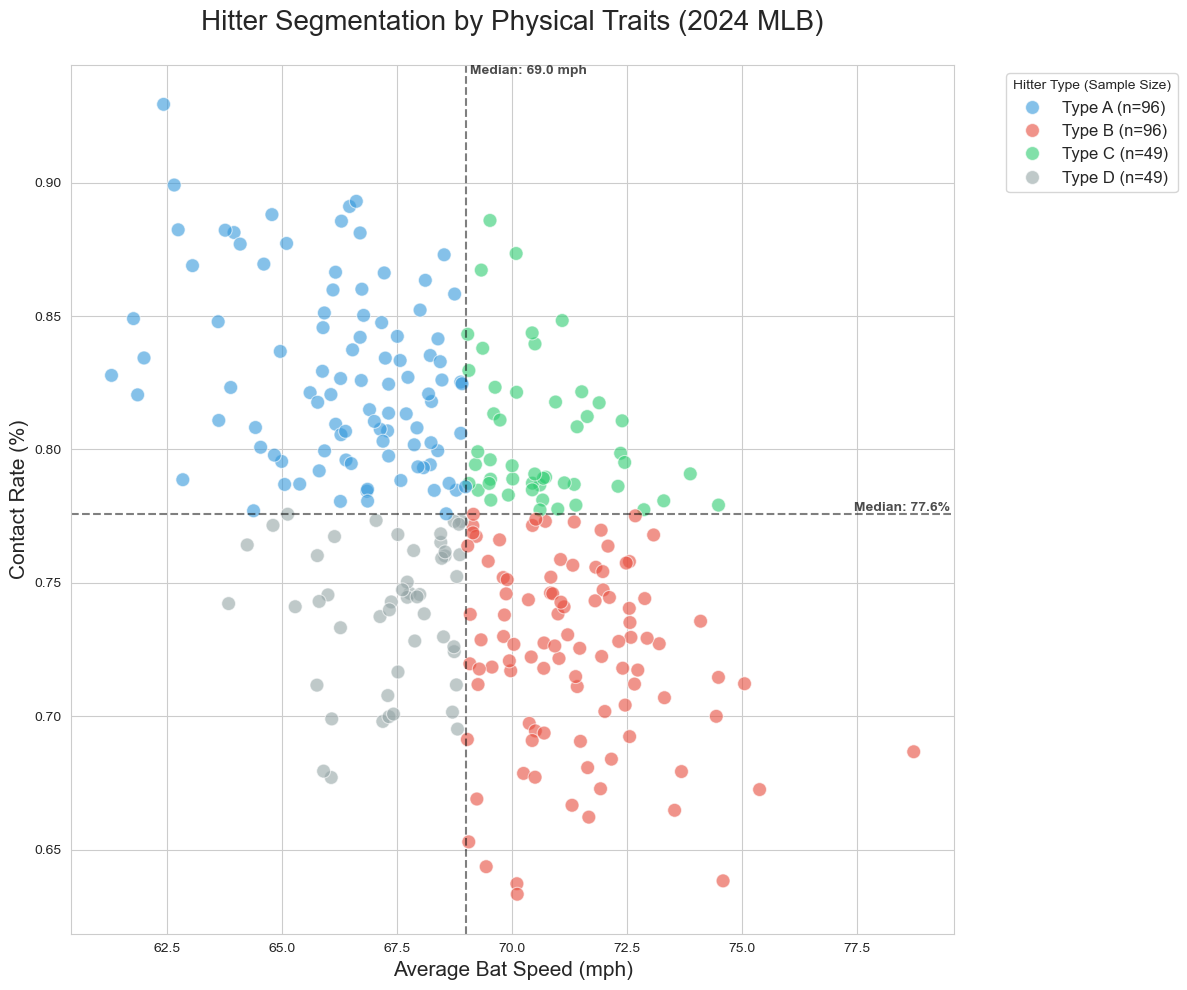

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Directory Setup
base_dir = os.path.dirname(os.getcwd()) 
data_dir = os.path.join(base_dir, 'data', 'processed')
image_dir = os.path.join(base_dir, 'images')

# Ensure the images directory exists
os.makedirs(image_dir, exist_ok=True)

input_path = os.path.join(data_dir, 'hitter_master_data.csv')
output_data_path = os.path.join(data_dir, 'hitter_classified_data.csv')
output_image_path = os.path.join(image_dir, '02_hitter_segmentation_map.png')

# 2. Load Data
if not os.path.exists(input_path):
    print(f"❌ File not found: {input_path}")
    print("Please run 01_data_collection.ipynb first to generate the dataset.")
else:
    df = pd.read_csv(input_path)

    # 3. Establish Classification Thresholds (Median)
    # Using Median ensures a balanced distribution across the four quadrants
    bat_speed_median = df['avg_bat_speed'].median()
    contact_pct_median = df['contact_pct'].median()

    print(f"📊 Classification Thresholds (Median):")
    print(f" - Bat Speed: {bat_speed_median:.1f} mph")
    print(f" - Contact %: {contact_pct_median*100:.1f} %")

    # 4. Define Quadrant Classification Logic
    def classify_type(row):
        speed = row['avg_bat_speed']
        contact = row['contact_pct']
        
        if speed >= bat_speed_median and contact >= contact_pct_median:
            return 'Type C' # High Speed, High Contact (Elite Hybrid)
        elif speed < bat_speed_median and contact >= contact_pct_median:
            return 'Type A' # Low Speed, High Contact (Pure Contact)
        elif speed >= bat_speed_median and contact < contact_pct_median:
            return 'Type B' # High Speed, Low Contact (Pure Power)
        else:
            return 'Type D' # Low Speed, Low Contact (Role Player)

    # 5. Apply Classification to DataFrame
    df['hitter_type'] = df.apply(classify_type, axis=1)

    # 6. Quadrant Visualization (Master Map)
    plt.figure(figsize=(12, 10), facecolor='white')
    sns.set_style("whitegrid")
    
    # Define color palette
    palette = {'Type A': '#3498db', 'Type B': '#e74c3c', 
               'Type C': '#2ecc71', 'Type D': '#95a5a6'}
    
    target_order = ['Type A', 'Type B', 'Type C', 'Type D']
    
    # 📍 NEW: Create dynamic labels with player counts for the legend
    counts = df['hitter_type'].value_counts()
    legend_labels = {t: f"{t} (n={counts.get(t, 0)})" for t in target_order}
    
    # Map the hitter_type to these new labels for plotting
    df['legend_type'] = df['hitter_type'].map(legend_labels)
    new_target_order = [legend_labels[t] for t in target_order]
    new_palette = {legend_labels[t]: palette[t] for t in target_order}

    scatter = sns.scatterplot(
        data=df, x='avg_bat_speed', y='contact_pct', 
        hue='legend_type',             # Use the new labels with counts
        hue_order=new_target_order,    # Maintain A-B-C-D order
        palette=new_palette, 
        alpha=0.6, 
        s=100                          # Slightly larger for better presentation
    )

    # Add median guide lines
    plt.axvline(bat_speed_median, color='black', linestyle='--', alpha=0.5)
    plt.axhline(contact_pct_median, color='black', linestyle='--', alpha=0.5)

    # Bat Speed Median Label
    plt.text(bat_speed_median, plt.ylim()[1], f' Median: {bat_speed_median:.1f} mph', 
             verticalalignment='top', horizontalalignment='left', 
             fontsize=10, color='black', weight='bold', alpha=0.7)
    
    # Contact Rate Median Label
    plt.text(plt.xlim()[1], contact_pct_median, f' Median: {contact_pct_median*100:.1f}% ', 
             verticalalignment='bottom', horizontalalignment='right', 
             fontsize=10, color='black', weight='bold', alpha=0.7)
    
    # Dynamic Label Positioning (Same as before)
    x_range = df['avg_bat_speed'].max() - df['avg_bat_speed'].min()
    y_range = df['contact_pct'].max() - df['contact_pct'].min()

    plt.title('Hitter Segmentation by Physical Traits (2024 MLB)', fontsize=20, pad=25)
    plt.xlabel('Average Bat Speed (mph)', fontsize=15)
    plt.ylabel('Contact Rate (%)', fontsize=15)
    
    # Legend with Player Counts
    plt.legend(title='Hitter Type (Sample Size)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
    
    # Save Data (Drop the temporary legend column before saving)
    df.drop(columns=['legend_type']).to_csv(output_data_path, index=False)